# Water Level prediction with Utide using secondary source of tidal constituents

In [18]:
import numpy as np
import utide
import datetime
import pickle
import matplotlib.pyplot as plt

## Harmonic constituents from somewhere (Maputo Bay, Mozambique)

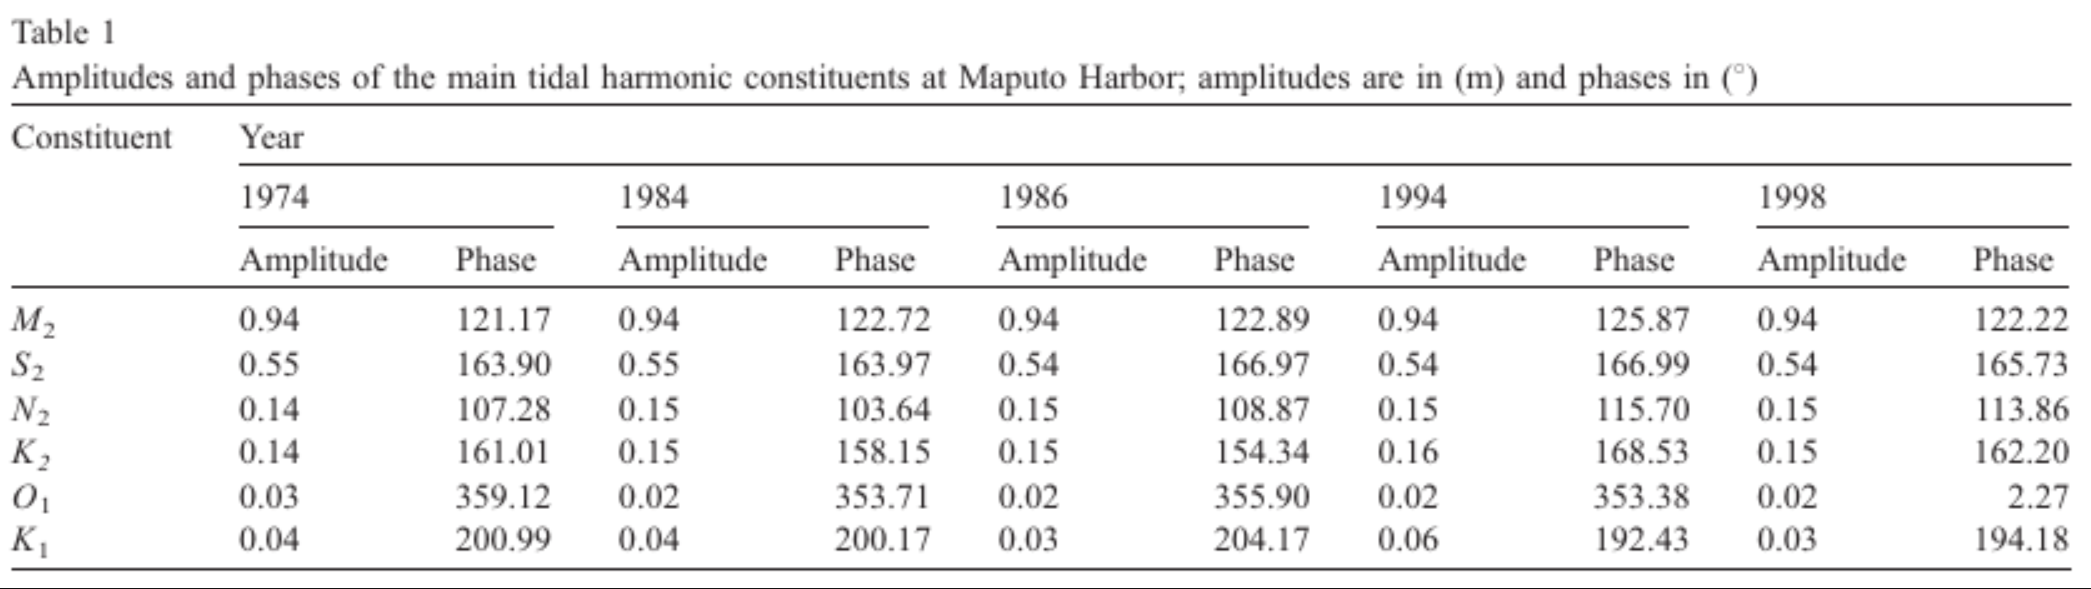

In [4]:
# for 1998
my_names = np.array(['M2', 'S2', 'N2', 'K2', 'O1', 'K1'])
my_A = np.array([0.94, 0.54, 0.15, 0.15, 0.02, 0.03])
my_g = np.array([122.22, 165.73, 113.86, 162.20, 2.27, 194.18])

## Getting the utide harmonic constants

In [8]:
path = r'c:\Python311\Lib\site-packages\utide\data\\'
ut_constants = np.load(path + 'ut_constants.npz', allow_pickle=True, encoding='bytes')

x = ut_constants['const'].item()   #Chatgpt... how to access the structure data

ut_names = x[b'name']
ut_freqs = x[b'freq']

## Separating the freqs and lints for the constituents we have!

In [9]:
my_lint = []
my_freqs = []
for name in my_names:
    for i, ut_name in enumerate(ut_names):
        if name == ut_name.strip():
            my_lint.append(i)
            my_freqs.append(ut_freqs[i])

print(my_lint)
print(my_freqs)

[47, 56, 41, 58, 12, 20]
[0.0805114007, 0.0833333333, 0.0789992488, 0.0835614924, 0.0387306544, 0.0417807462]


## Creating a dummy bunch

In [13]:
t = np.array([datetime.datetime(2000,1,1,1), datetime.datetime(2000,1,1,2)])
n = np.array([0, 0])
coef = utide.solve(t, n, v=None, lat=0.1)

solve: matrix prep ... solution ... done.


## Inserting the stuff in the bunch

In [14]:
coef['name'] = my_names
coef['A'] = my_A
coef['g'] = my_g
coef['A_ci'] = np.zeros_like(my_A)
coef['aux']['frq'] = np.array(my_freqs)
coef['aux']['lind'] = np.array(my_lint)

## Some real data to compare (using the same time for the reconstruct)!

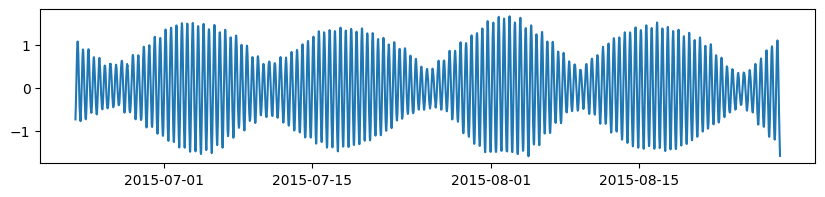

In [19]:
with open('Maputo_waterlevel.pkl', 'rb') as io:
    mwl = pickle.load(io)

m_time = mwl[0]   # it is in GMT
m_wl = mwl[1] - np.mean(mwl[1])

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)

## Doing the prediction

In [20]:
bunch = utide.reconstruct(m_time, coef)

prep/calcs ... done.


C:\Python311\Lib\site-packages\utide\_reconstruct.py:109: RuntimeWarning: divide by zero encountered in divide
  SNR = E / N


## The result

(16611.0, 16631.0)

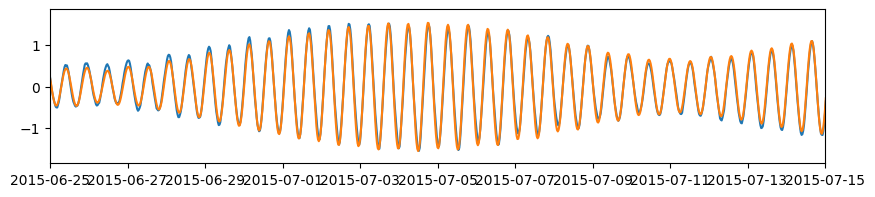

In [22]:
h = bunch['h']

l1 = datetime.datetime(2015, 6, 25)
l2 = datetime.datetime(2015, 7, 15)

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)
plt.plot(m_time, h)
plt.xlim(l1, l2)